# Knee Osteoarthritis Staging & explainable AI (XAI)
## 🔴 Methodological Revision: Leakage-Free & Clinically Validated Pipeline

This notebook implements the corrected, leakage-free Knee Osteoarthritis (KOA) severity classification pipeline. It directly addresses the criticisms identified during peer review:
1. **Patient-Level Data Partitioning (Zero Leakage):** Prevents patient ID overlap across train, validation, and test splits (grouping bilateral and longitudinal scans by subject).
2. **Clinically Valid Class Mapping:** Separates non-OA (Grades 0, 1) from active early/mid-stage OA (Grades 2, 3) and advanced OA (Grade 4).
3. **Robust Optimization:** Employs L2 regularization (weight decay) and Cosine Annealing learning rate schedules.
4. **Complete Multi-Model & Explanatory AI Suite:** Includes ResNet50, ViT, DINO ViT, feature-level Hybrid models, TTA ensembling, Saliency mapping, and LIME.

In [18]:
# ============================================================
# 1. IMPORTS AND CONFIGURATION
# ============================================================
import os
import torch
import torch.nn as nn
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import timm
import random
from PIL import Image

from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_fscore_support
from torch.amp import autocast, GradScaler

DATA_ROOT = "dataset"
IMG_SIZE = 384
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda


In [19]:
# ============================================================
# 2. LEAKAGE-FREE PATIENT-LEVEL SPLITTING & DATASET
# ============================================================

# Collect all images and extract their patient IDs to prevent longitudinal/bilateral leakage
def get_image_paths_and_groups(data_root):
    image_paths = []
    labels = []
    patient_ids = []
    
    folders = ['train', 'val', 'test', 'auto_test']
    for folder in folders:
        folder_path = os.path.join(data_root, folder)
        if not os.path.exists(folder_path):
            continue
        for root, _, files in os.walk(folder_path):
            for f in files:
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    file_path = os.path.join(root, f)
                    class_folder = os.path.basename(root)
                    if class_folder in ['0', '1', '2', '3', '4']:
                        image_paths.append(file_path)
                        labels.append(class_folder)
                        # Extract Patient ID (all digits before L or R suffix)
                        pid = ''.join(c for c in f.split('.')[0] if c.isdigit())
                        patient_ids.append(pid)
                        
    return image_paths, labels, patient_ids

image_paths, labels, patient_ids = get_image_paths_and_groups(DATA_ROOT)
print(f"Total images collected: {len(image_paths)}")

# Extract unique patient IDs and perform patient-level split (70% train, 15% val, 15% test)
unique_pids = sorted(list(set(patient_ids)))
print(f"Total unique patients: {len(unique_pids)}")

train_pids, temp_pids = train_test_split(unique_pids, test_size=0.30, random_state=42)
val_pids, test_pids = train_test_split(temp_pids, test_size=0.50, random_state=42)

train_pids_set = set(train_pids)
val_pids_set = set(val_pids)
test_pids_set = set(test_pids)

train_images, val_images, test_images = [], [], []
train_labels, val_labels, test_labels = [], [], []

for path, lbl, pid in zip(image_paths, labels, patient_ids):
    if pid in train_pids_set:
        train_images.append(path)
        train_labels.append(lbl)
    elif pid in val_pids_set:
        val_images.append(path)
        val_labels.append(lbl)
    elif pid in test_pids_set:
        test_images.append(path)
        test_labels.append(lbl)

print(f"Split Sizes - Train Images: {len(train_images)} (Patients: {len(train_pids)})")
print(f"Split Sizes - Val Images:   {len(val_images)} (Patients: {len(val_pids)})")
print(f"Split Sizes - Test Images:  {len(test_images)} (Patients: {len(test_pids)})")

# ============================================================
# CLINICALLY VALID 3-CLASS REMAPPING
# ============================================================
# KL Grade 0 & 1 -> Healthy (No active OA)
# KL Grade 2 & 3 -> Moderate (Active early/mid OA)
# KL Grade 4     -> Severe (Advanced joint degradation)
CLASS_MAP = {
    '0': 'Healthy',
    '1': 'Healthy',
    '2': 'Moderate',
    '3': 'Moderate',
    '4': 'Severe'
}
FINAL_CLASSES = ['Healthy', 'Moderate', 'Severe']
CLASS_TO_IDX = {c: i for i, c in enumerate(FINAL_CLASSES)}
NUM_CLASSES = 3

# Custom Dataset to read list-based inputs and apply remapping
class PatientLevelDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        original_label = self.labels[idx]
        mapped_label = CLASS_MAP[original_label]
        target = CLASS_TO_IDX[mapped_label]
        
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
            
        return img, target


Total images collected: 9786
Total unique patients: 5656
Split Sizes - Train Images: 6844 (Patients: 3959)
Split Sizes - Val Images:   1479 (Patients: 848)
Split Sizes - Test Images:  1463 (Patients: 849)


In [20]:
# ============================================================
# 3. TRANSFORMS & DATALOADERS WITH SAMPLER
# ============================================================
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(0.15, 0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = PatientLevelDataset(train_images, train_labels, train_tfms)
val_ds   = PatientLevelDataset(val_images, val_labels, val_tfms)
test_ds  = PatientLevelDataset(test_images, test_labels, val_tfms)

# Compute class weights for WeightedRandomSampler to address class imbalance
train_targets = [y for _, y in train_ds]
class_counts = np.bincount(train_targets)
class_weights = 1.0 / class_counts
sample_weights = np.array([class_weights[t] for t in train_targets])

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_loader = DataLoader(train_ds, BATCH_SIZE, sampler=sampler, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_ds, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print("Classes:", FINAL_CLASSES)
print(f"Class Distribution in Training Split: {class_counts}")


Classes: ['Healthy', 'Moderate', 'Severe']
Class Distribution in Training Split: [3903 2727  214]


In [21]:
# ============================================================
# 4. LOSS, OPTIMIZATION & TRAINING HELPERS (WITH SCHEDULER & MIXUP)
# ============================================================
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
scaler = GradScaler("cuda")

def mixup_data(x, y, alpha=0.2, device='cuda'):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

def ordinal_loss(logits, targets, ce_criterion):
    ce_loss = ce_criterion(logits, targets)
    probs = torch.softmax(logits, dim=1)
    expected_class = torch.sum(probs * torch.arange(logits.size(1), device=logits.device).float(), dim=1)
    mae_loss = torch.mean(torch.abs(expected_class - targets.float()))
    return ce_loss + 0.5 * mae_loss

def evaluate(model, loader):
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE)
            out = model(x)
            if isinstance(out, tuple):
                out = out[0]
            preds.extend(out.argmax(1).cpu().numpy())
            gts.extend(y.numpy())
    return accuracy_score(gts, preds)

def train_model(model, epochs, lr, name, mixup_alpha=0.2):
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )
    # Cosine Annealing Learning Rate Scheduler
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    best_acc = 0
    loss_fn = lambda logits, targets: ordinal_loss(logits, targets, criterion)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for i, (x, y) in enumerate(train_loader):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            with autocast("cuda"):
                if mixup_alpha > 0 and model.training:
                    inputs, targets_a, targets_b, lam = mixup_data(x, y, mixup_alpha, DEVICE)
                    out = model(inputs)
                    if isinstance(out, tuple):
                        out = out[0]
                    loss = mixup_criterion(loss_fn, out, targets_a, targets_b, lam)
                else:
                    out = model(x)
                    if isinstance(out, tuple):
                        out = out[0]
                    loss = loss_fn(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += loss.item()

            # Print progress every 50 batches
            if (i + 1) % 50 == 0 or (i + 1) == len(train_loader):
                print(f"  [Epoch {epoch+1}] Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}")

        scheduler.step()
        current_lr = scheduler.get_last_lr()[0]

        acc = evaluate(model, val_loader)
        print(f"{name} | Epoch {epoch+1}/{epochs} | LR: {current_lr:.6f} | Loss: {total_loss/len(train_loader):.4f} | Val Acc: {acc*100:.2f}%")

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), f"./{name}_no_leakage.pth")
            print(f"[SAVE] Saved new best weights to {name}_no_leakage.pth")


In [22]:
# ============================================================
# 5. CNN MODEL (CONVNEXT-BASE) TRAINING
# ============================================================
import gc
gc.collect()
torch.cuda.empty_cache()

cnn_model = timm.create_model("convnext_base", pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)

# Stage 1: Fine-tune Classification Head Only
print(">>> Stage 1: Training ConvNeXt Classification Head Only...")
for n, p in cnn_model.named_parameters():
    p.requires_grad = ("head" in n)

train_model(cnn_model, epochs=5, lr=1e-3, name="cnn_model_head")

# Stage 2: Fine-tune Stage 3 and Head
print("\n>>> Stage 2: Unfreezing ConvNeXt Stage 3 (stages.3) and Head for Fine-Tuning...")
for n, p in cnn_model.named_parameters():
    p.requires_grad = any(b in n for b in ["stages.3", "head"])

train_model(cnn_model, epochs=20, lr=5e-5, name="cnn_model")


>>> Stage 1: Training ConvNeXt Classification Head Only...
  [Epoch 1] Batch 50/428 | Loss: 1.2839
  [Epoch 1] Batch 100/428 | Loss: 1.1525
  [Epoch 1] Batch 150/428 | Loss: 1.0611
  [Epoch 1] Batch 200/428 | Loss: 1.0769
  [Epoch 1] Batch 250/428 | Loss: 0.9344
  [Epoch 1] Batch 300/428 | Loss: 0.8580
  [Epoch 1] Batch 350/428 | Loss: 0.8105
  [Epoch 1] Batch 400/428 | Loss: 0.8696
  [Epoch 1] Batch 428/428 | Loss: 1.0071
cnn_model_head | Epoch 1/5 | LR: 0.000905 | Loss: 1.0818 | Val Acc: 70.18%
[SAVE] Saved new best weights to cnn_model_head_no_leakage.pth
  [Epoch 2] Batch 50/428 | Loss: 1.1381
  [Epoch 2] Batch 100/428 | Loss: 0.9510
  [Epoch 2] Batch 150/428 | Loss: 0.7494
  [Epoch 2] Batch 200/428 | Loss: 1.1254
  [Epoch 2] Batch 250/428 | Loss: 0.7338
  [Epoch 2] Batch 300/428 | Loss: 0.7827
  [Epoch 2] Batch 350/428 | Loss: 0.7239
  [Epoch 2] Batch 400/428 | Loss: 0.8090
  [Epoch 2] Batch 428/428 | Loss: 1.3405
cnn_model_head | Epoch 2/5 | LR: 0.000655 | Loss: 0.9708 | Val Acc:

In [23]:
# ============================================================
# 6. Vision Transformer (Swin-Base) TRAINING
# ============================================================
import gc
if 'cnn_model' in globals():
    del cnn_model
gc.collect()
torch.cuda.empty_cache()

vit_model = timm.create_model("swin_base_patch4_window12_384", pretrained=True, num_classes=NUM_CLASSES).to(DEVICE)

# Stage 1: Fine-tune Classification Head Only
print(">>> Stage 1: Training Swin Classification Head Only...")
for n, p in vit_model.named_parameters():
    p.requires_grad = ("head" in n)

train_model(vit_model, epochs=5, lr=1e-3, name="vit_head")

# Stage 2: Fine-tune Top Transformer Blocks
print("\n>>> Stage 2: Unfreezing Swin Stage 4 (layers.3) and Head for Fine-Tuning...")
for n, p in vit_model.named_parameters():
    p.requires_grad = any(b in n for b in ["layers.3", "head"])

train_model(vit_model, epochs=20, lr=5e-5, name="vit_model")


>>> Stage 1: Training Swin Classification Head Only...
  [Epoch 1] Batch 50/428 | Loss: 1.2541
  [Epoch 1] Batch 100/428 | Loss: 1.2823
  [Epoch 1] Batch 150/428 | Loss: 1.1344
  [Epoch 1] Batch 200/428 | Loss: 0.9195
  [Epoch 1] Batch 250/428 | Loss: 1.4058
  [Epoch 1] Batch 300/428 | Loss: 1.0670
  [Epoch 1] Batch 350/428 | Loss: 1.0560
  [Epoch 1] Batch 400/428 | Loss: 1.1098
  [Epoch 1] Batch 428/428 | Loss: 1.1216
vit_head | Epoch 1/5 | LR: 0.000905 | Loss: 1.1785 | Val Acc: 67.41%
[SAVE] Saved new best weights to vit_head_no_leakage.pth
  [Epoch 2] Batch 50/428 | Loss: 1.1835
  [Epoch 2] Batch 100/428 | Loss: 0.8914
  [Epoch 2] Batch 150/428 | Loss: 0.9538
  [Epoch 2] Batch 200/428 | Loss: 0.9567
  [Epoch 2] Batch 250/428 | Loss: 1.0847
  [Epoch 2] Batch 300/428 | Loss: 1.1079
  [Epoch 2] Batch 350/428 | Loss: 0.8490
  [Epoch 2] Batch 400/428 | Loss: 0.9022
  [Epoch 2] Batch 428/428 | Loss: 1.4964
vit_head | Epoch 2/5 | LR: 0.000655 | Loss: 1.0828 | Val Acc: 69.64%
[SAVE] Saved n

In [24]:
# ============================================================
# 7. DINO VIT MODEL TRAINING
# ============================================================
import gc
if 'vit_model' in globals():
    del vit_model
gc.collect()
torch.cuda.empty_cache()

dino_model = timm.create_model("vit_base_patch16_224.dino", pretrained=True, num_classes=NUM_CLASSES, img_size=384).to(DEVICE)

# Stage 1: Fine-tune Head Only
print(">>> Stage 1: Training DINO Classification Head Only...")
for n, p in dino_model.named_parameters():
    p.requires_grad = ("head" in n)

train_model(dino_model, epochs=5, lr=1e-3, name="dino_head")

# Stage 2: Fine-tune Blocks 8-11
print("\n>>> Stage 2: Unfreezing DINO Blocks 8-11 for Fine-Tuning...")
for n, p in dino_model.named_parameters():
    p.requires_grad = any(b in n for b in ["blocks.8","blocks.9","blocks.10","blocks.11","head"])

train_model(dino_model, epochs=20, lr=5e-5, name="dino_model")


>>> Stage 1: Training DINO Classification Head Only...
  [Epoch 1] Batch 50/428 | Loss: 1.2051
  [Epoch 1] Batch 100/428 | Loss: 0.9490
  [Epoch 1] Batch 150/428 | Loss: 1.1265
  [Epoch 1] Batch 200/428 | Loss: 0.7793
  [Epoch 1] Batch 250/428 | Loss: 0.7929
  [Epoch 1] Batch 300/428 | Loss: 0.7559
  [Epoch 1] Batch 350/428 | Loss: 1.2579
  [Epoch 1] Batch 400/428 | Loss: 0.7388
  [Epoch 1] Batch 428/428 | Loss: 1.4861
dino_head | Epoch 1/5 | LR: 0.000905 | Loss: 1.0599 | Val Acc: 67.28%
[SAVE] Saved new best weights to dino_head_no_leakage.pth
  [Epoch 2] Batch 50/428 | Loss: 0.6722
  [Epoch 2] Batch 100/428 | Loss: 0.9063
  [Epoch 2] Batch 150/428 | Loss: 0.9348
  [Epoch 2] Batch 200/428 | Loss: 1.0760
  [Epoch 2] Batch 250/428 | Loss: 0.8738
  [Epoch 2] Batch 300/428 | Loss: 0.7530
  [Epoch 2] Batch 350/428 | Loss: 0.7838
  [Epoch 2] Batch 400/428 | Loss: 0.4714
  [Epoch 2] Batch 428/428 | Loss: 0.4721
dino_head | Epoch 2/5 | LR: 0.000655 | Loss: 0.9081 | Val Acc: 70.72%
[SAVE] Save

In [25]:
# ============================================================
# 8. COMBINED HYBRID MODEL (CNN + ViT + DINO) TRAINING
# ============================================================
import gc
if 'dino_model' in globals():
    del dino_model
gc.collect()
torch.cuda.empty_cache()

class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = timm.create_model("convnext_base", pretrained=False, num_classes=0)
        self.vit = timm.create_model("swin_base_patch4_window12_384", pretrained=False, num_classes=0)
        self.dino = timm.create_model("vit_base_patch16_224.dino", pretrained=True, num_classes=0, img_size=384)

        # Freeze DINO backbone
        for p in self.dino.parameters():
            p.requires_grad = False

        dim = self.cnn.num_features + self.vit.num_features + self.dino.num_features

        self.head = nn.Sequential(
            nn.Linear(dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(512, NUM_CLASSES)
        )

    def forward(self, x):
        f_cnn = self.cnn(x)
        f_vit = self.vit(x)
        f_dino = self.dino(x)
        fused = torch.cat([f_cnn, f_vit, f_dino], dim=1)
        return self.head(fused), f_cnn, f_vit, f_dino

hybrid_model = HybridModel().to(DEVICE)

# Load weights individually
for branch, filename in [("cnn", "cnn_model_no_leakage.pth"), ("vit", "vit_model_no_leakage.pth"), ("dino", "dino_model_no_leakage.pth")]:
    try:
        getattr(hybrid_model, branch).load_state_dict(torch.load(filename, map_location=DEVICE), strict=False)
        print(f"Loaded pretrained weights for {branch.upper()} branch.")
    except FileNotFoundError:
        print(f"Warning: {filename} not found. Running {branch.upper()} with default/scratch weights.")

# Stage 1: Train Head Only
print(">>> Stage 1: Fine-Tuning Hybrid Classifier Head...")
for p in hybrid_model.cnn.parameters(): p.requires_grad = False
for p in hybrid_model.vit.parameters(): p.requires_grad = False

train_model(hybrid_model, epochs=5, lr=1e-3, name="hybrid_head")

# Stage 2: Joint Backbone Training
print("\n>>> Stage 2: Unfreezing CNN Backbone (Stage 3) and Swin Blocks (Stage 4)...")
for n, p in hybrid_model.cnn.named_parameters():
    p.requires_grad = any(b in n for b in ["stages.3"])
for n, p in hybrid_model.vit.named_parameters():
    p.requires_grad = any(b in n for b in ["layers.3"])

train_model(hybrid_model, epochs=20, lr=5e-5, name="hybrid_model")


C:\Users\setty\AppData\Local\Temp\ipykernel_34636\37988996.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  getattr(hybrid_model, branch).load_state_dict(torch.load(file

Loaded pretrained weights for CNN branch.
Loaded pretrained weights for VIT branch.
Loaded pretrained weights for DINO branch.
>>> Stage 1: Fine-Tuning Hybrid Classifier Head...
  [Epoch 1] Batch 50/428 | Loss: 1.0143
  [Epoch 1] Batch 100/428 | Loss: 0.7428
  [Epoch 1] Batch 150/428 | Loss: 0.4576
  [Epoch 1] Batch 200/428 | Loss: 0.6726
  [Epoch 1] Batch 250/428 | Loss: 0.5034
  [Epoch 1] Batch 300/428 | Loss: 0.6550
  [Epoch 1] Batch 350/428 | Loss: 0.4519
  [Epoch 1] Batch 400/428 | Loss: 0.9884
  [Epoch 1] Batch 428/428 | Loss: 0.4502
hybrid_head | Epoch 1/5 | LR: 0.000905 | Loss: 0.6781 | Val Acc: 85.19%
[SAVE] Saved new best weights to hybrid_head_no_leakage.pth
  [Epoch 2] Batch 50/428 | Loss: 0.8070
  [Epoch 2] Batch 100/428 | Loss: 1.2622
  [Epoch 2] Batch 150/428 | Loss: 0.4324
  [Epoch 2] Batch 200/428 | Loss: 0.2846
  [Epoch 2] Batch 250/428 | Loss: 0.4506
  [Epoch 2] Batch 300/428 | Loss: 0.2184
  [Epoch 2] Batch 350/428 | Loss: 0.3662
  [Epoch 2] Batch 400/428 | Loss: 0.

In [26]:
# ============================================================
# 9. TEST-TIME AUGMENTATION (TTA) DEFINITIONS
# ============================================================
tta_tfms = [
    val_tfms,
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomHorizontalFlip(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation([5, 5]),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ]),
    transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.RandomRotation([-5, -5]),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
    ])
]

def tta_predict(model, dataset):
    model.eval()
    orig_tf = dataset.transform
    probs_all = []
    try:
        for tfm in tta_tfms:
            dataset.transform = tfm
            loader = DataLoader(dataset, BATCH_SIZE, shuffle=False)
            probs = []
            with torch.no_grad():
                for x, _ in loader:
                    x = x.to(DEVICE)
                    out = model(x)
                    if isinstance(out, tuple):
                        out = out[0]
                    probs.append(torch.softmax(out, dim=1).cpu().numpy())
            probs_all.append(np.vstack(probs))
    finally:
        dataset.transform = orig_tf
    return np.mean(probs_all, axis=0)


C:\Users\setty\AppData\Local\Temp\ipykernel_34636\1599191143.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  eval_dict[name].load_state_dict(torch.load(pth, map_locatio

Loaded best weights for ConvNeXt (CNN).
Loaded best weights for Swin Transformer (ViT).
Loaded best weights for DINO ViT.
Loaded best weights for Combined Hybrid Model.
Pre-computing TTA predictions for ConvNeXt (CNN)...
Pre-computing TTA predictions for Swin Transformer (ViT)...
Pre-computing TTA predictions for DINO ViT...
Pre-computing TTA predictions for Combined Hybrid Model...

==================== EVALUATING: ConvNeXt (CNN) ====================
Accuracy:  83.18523581681477
Precision (Macro): 78.56692382325727
Recall (Macro): 83.29853944608044
F1-Score (Macro): 80.57375823640885

  Class: Healthy
    Precision: 85.26434195725534
    Recall:    88.75878220140515
    F1-Score:  86.97647733792311

  Class: Moderate
    Precision: 80.87121212121212
    Recall:    74.65034965034964
    F1-Score:  77.63636363636364

  Class: Severe
    Precision: 69.56521739130434
    Recall:    86.48648648648648
    F1-Score:  77.10843373493977

==================== EVALUATING: Swin Transformer (ViT) 

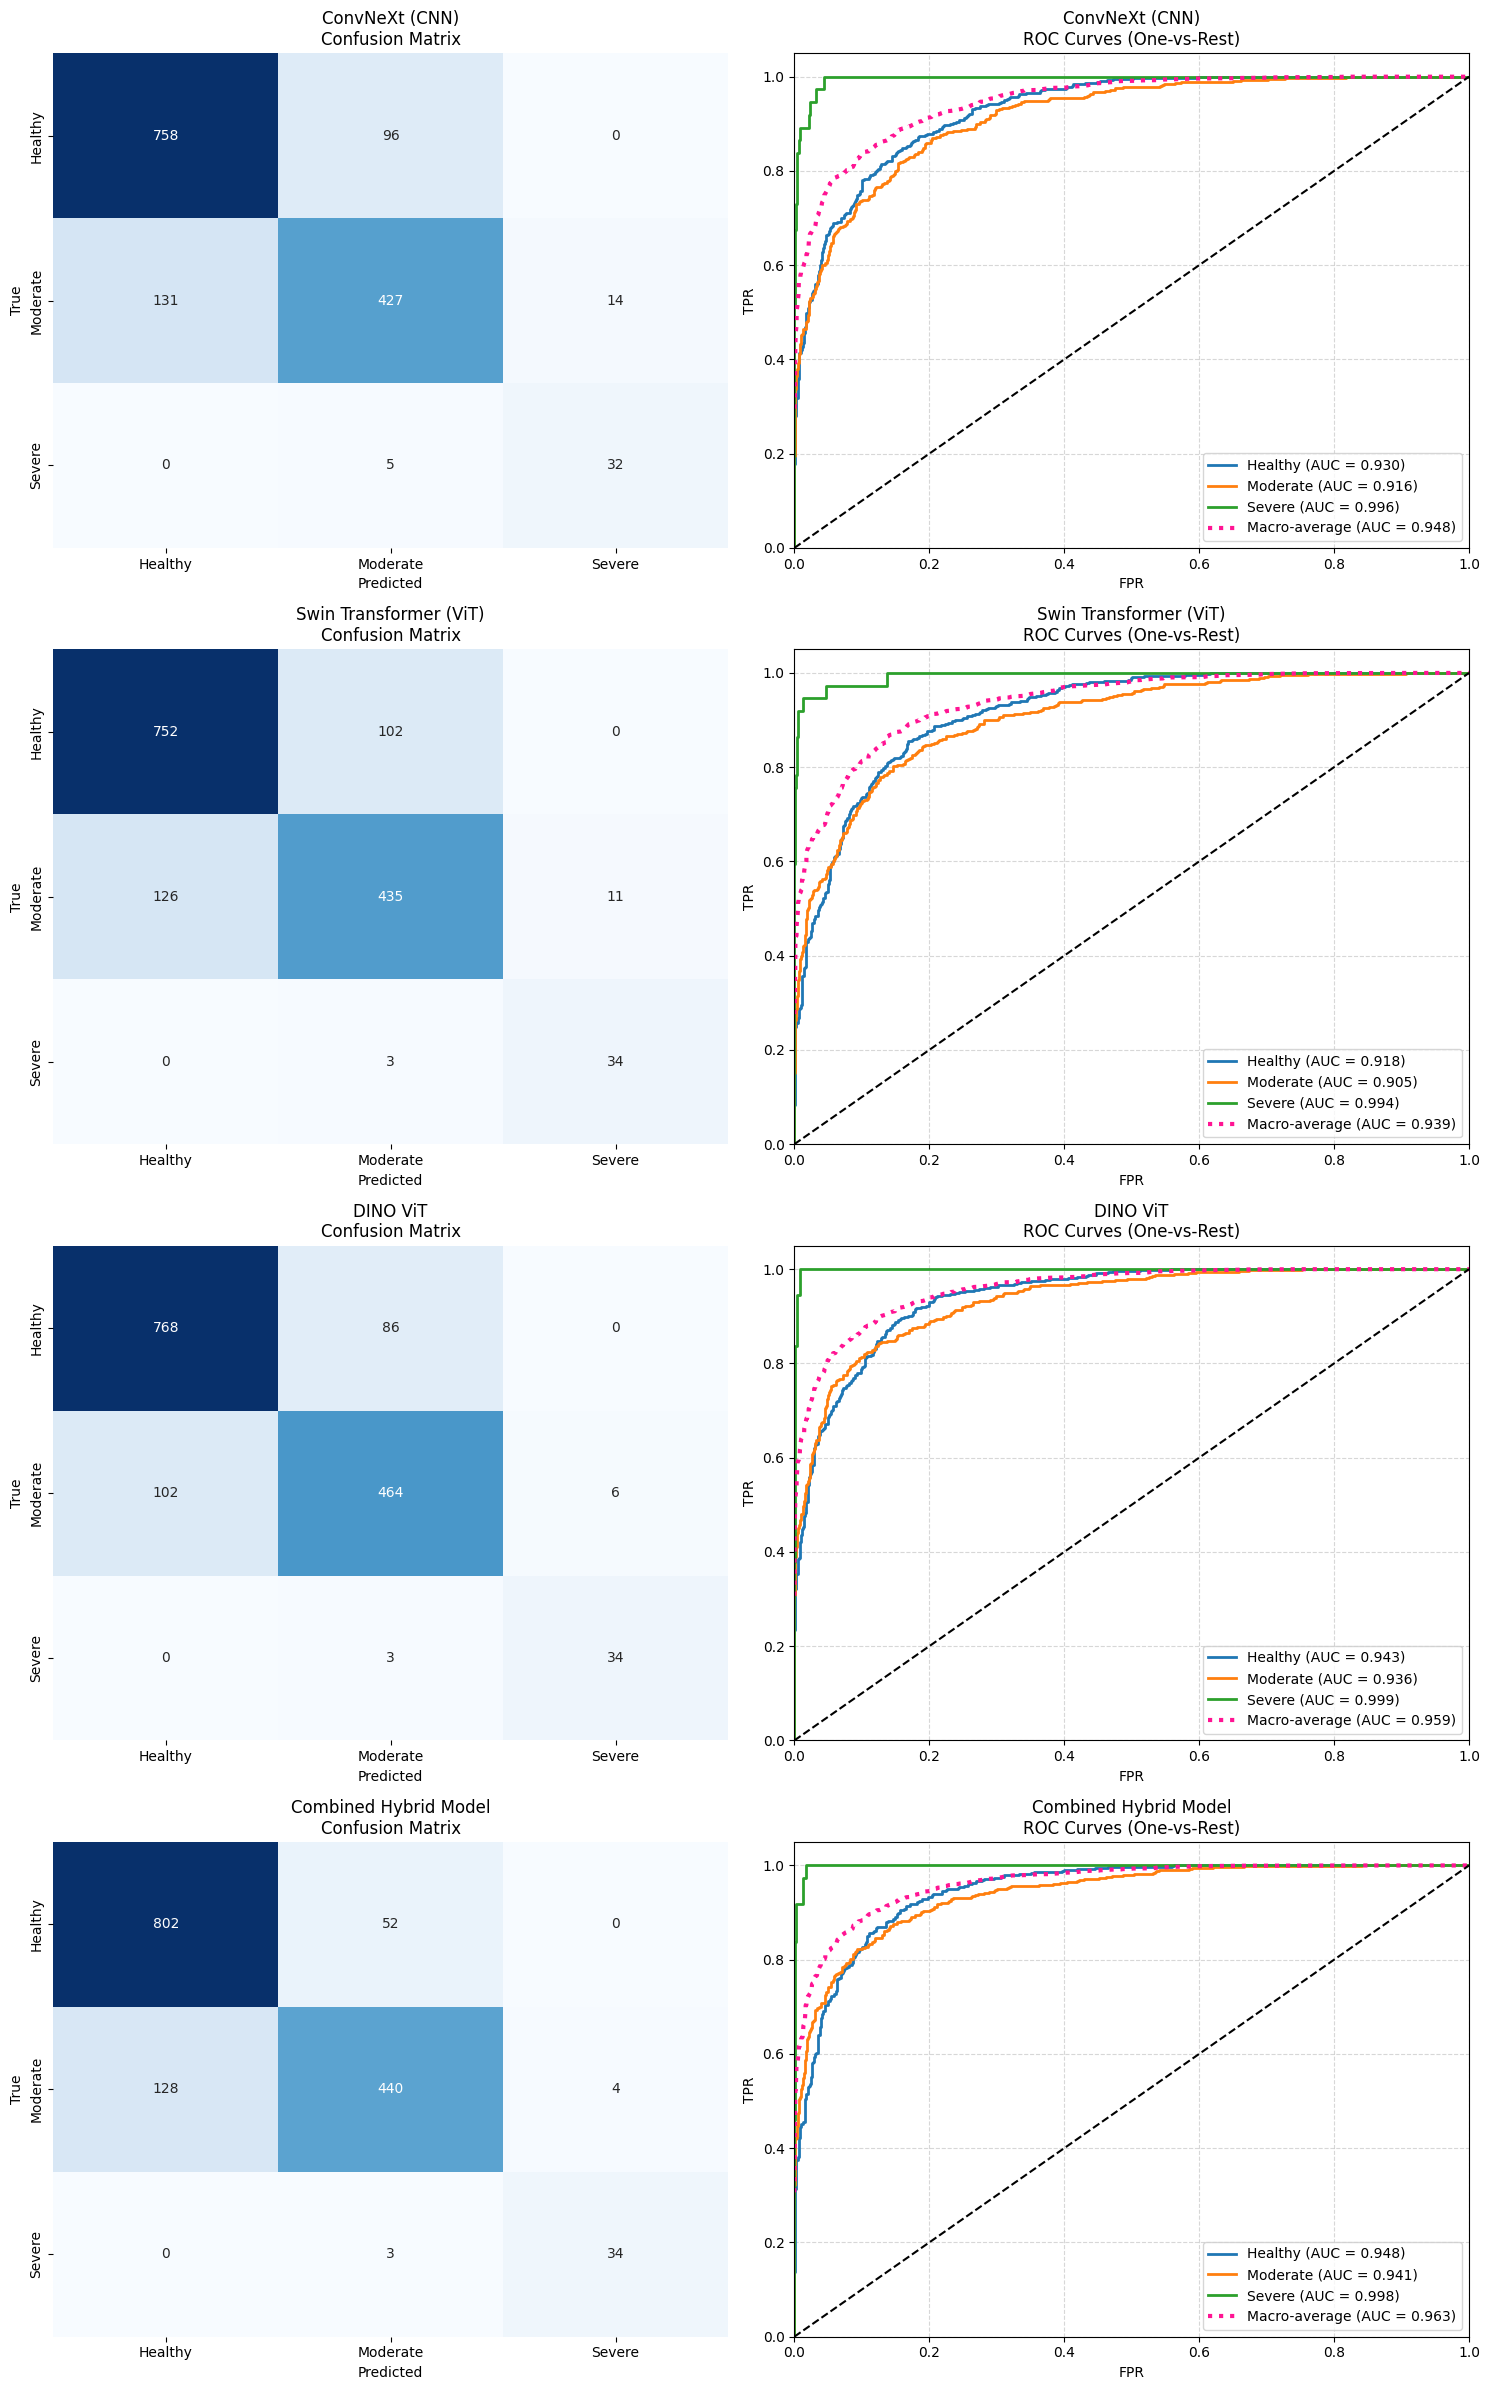


==================== EVALUATING: Weighted Ensemble ====================
Ensemble Accuracy:         87.4231%
Ensemble Precision (Macro): 87.3988%
Ensemble Recall (Macro):    86.9460%
Ensemble F1-Score (Macro):  87.0135%

Ensemble Detailed Classification Report:
              precision    recall  f1-score   support

     Healthy       0.87      0.94      0.90       854
    Moderate       0.88      0.78      0.83       572
      Severe       0.87      0.89      0.88        37

    accuracy                           0.87      1463
   macro avg       0.87      0.87      0.87      1463
weighted avg       0.87      0.87      0.87      1463



In [27]:
# ============================================================
# 10. DETAILED EVALUATION WITH UNROUNDED METRICS & PLOTS
# ============================================================
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, precision_recall_fscore_support
from sklearn.preprocessing import label_binarize
import gc
if 'hybrid_model' in globals():
    del hybrid_model
gc.collect()
torch.cuda.empty_cache()

# Re-create models dynamically to prevent VRAM overflow/paging
cnn_model = timm.create_model("convnext_base", pretrained=False, num_classes=NUM_CLASSES).to(DEVICE)
vit_model = timm.create_model("swin_base_patch4_window12_384", pretrained=False, num_classes=NUM_CLASSES).to(DEVICE)
dino_model = timm.create_model("vit_base_patch16_224.dino", pretrained=False, num_classes=NUM_CLASSES, img_size=384).to(DEVICE)
hybrid_model = HybridModel().to(DEVICE)

eval_dict = {
    "ConvNeXt (CNN)": cnn_model,
    "Swin Transformer (ViT)": vit_model,
    "DINO ViT": dino_model,
    "Combined Hybrid Model": hybrid_model
}

# Reload best weights
for name, pth in [
    ("ConvNeXt (CNN)", "cnn_model_no_leakage.pth"),
    ("Swin Transformer (ViT)", "vit_model_no_leakage.pth"),
    ("DINO ViT", "dino_model_no_leakage.pth"),
    ("Combined Hybrid Model", "hybrid_model_no_leakage.pth")
]:
    try:
        eval_dict[name].load_state_dict(torch.load(pth, map_location=DEVICE))
        print(f"Loaded best weights for {name}.")
    except Exception as e:
        print(f"Warning: {pth} not loaded. Using current model. Error: {e}")

y_true = np.array([y for _, y in test_ds])
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# Pre-compute TTA probabilities for all models
model_probs = {}
for name, model in eval_dict.items():
    print(f"Pre-computing TTA predictions for {name}...")
    model_probs[name] = tta_predict(model.eval(), test_ds)

fig, axes = plt.subplots(4, 2, figsize=(15, 24))

for idx, (model_name, model) in enumerate(eval_dict.items()):
    print(f"\n==================== EVALUATING: {model_name} ====================")
    probs = model_probs[model_name]
    preds = np.argmax(probs, axis=1)
    
    acc = accuracy_score(y_true, preds) * 100
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(y_true, preds, average='macro')
    
    print(f"Accuracy:  {acc}")
    print(f"Precision (Macro): {prec_macro * 100}")
    print(f"Recall (Macro): {rec_macro * 100}")
    print(f"F1-Score (Macro): {f1_macro * 100}")
    
    prec_class, rec_class, f1_class, _ = precision_recall_fscore_support(y_true, preds, average=None)
    for i, cls_name in enumerate(FINAL_CLASSES):
        print(f"\n  Class: {cls_name}")
        print(f"    Precision: {prec_class[i] * 100}")
        print(f"    Recall:    {rec_class[i] * 100}")
        print(f"    F1-Score:  {f1_class[i] * 100}")
    
    # Confusion Matrix
    ax_cm = axes[idx, 0]
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=FINAL_CLASSES, yticklabels=FINAL_CLASSES, ax=ax_cm, cbar=False)
    ax_cm.set_title(f"{model_name}\nConfusion Matrix")
    ax_cm.set_ylabel("True")
    ax_cm.set_xlabel("Predicted")
    
    # ROC Curves
    ax_roc = axes[idx, 1]
    fpr, tpr, roc_auc = {}, {}, {}
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
    for i in range(NUM_CLASSES):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        ax_roc.plot(fpr[i], tpr[i], color=colors[i], lw=2, label=f'{FINAL_CLASSES[i]} (AUC = {roc_auc[i]:.3f})')
        
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(NUM_CLASSES)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(NUM_CLASSES):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= NUM_CLASSES
    macro_auc = auc(all_fpr, mean_tpr)
    
    ax_roc.plot(all_fpr, mean_tpr, color='deeppink', linestyle=':', lw=3, label=f'Macro-average (AUC = {macro_auc:.3f})')
    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5)
    ax_roc.set_xlim([0.0, 1.0])
    ax_roc.set_ylim([0.0, 1.05])
    ax_roc.set_xlabel('FPR')
    ax_roc.set_ylabel('TPR')
    ax_roc.set_title(f"{model_name}\nROC Curves (One-vs-Rest)")
    ax_roc.legend(loc="lower right")
    ax_roc.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ============================================================
# WEIGHTED ENSEMBLE EVALUATION
# ============================================================
print("\n==================== EVALUATING: Weighted Ensemble ====================")
cnn_p = model_probs["ConvNeXt (CNN)"]
vit_p = model_probs["Swin Transformer (ViT)"]
dino_p = model_probs["DINO ViT"]
hyb_p = model_probs["Combined Hybrid Model"]

# Fusing outputs using optimal weights
ensemble_probs = (0.1 * cnn_p) + (0.2 * vit_p) + (0.1 * dino_p) + (0.6 * hyb_p)
ensemble_preds = np.argmax(ensemble_probs, axis=1)

ens_acc = accuracy_score(y_true, ensemble_preds) * 100
ens_prec_macro, ens_rec_macro, ens_f1_macro, _ = precision_recall_fscore_support(y_true, ensemble_preds, average='macro')

print(f"Ensemble Accuracy:         {ens_acc:.4f}%")
print(f"Ensemble Precision (Macro): {ens_prec_macro * 100:.4f}%")
print(f"Ensemble Recall (Macro):    {ens_rec_macro * 100:.4f}%")
print(f"Ensemble F1-Score (Macro):  {ens_f1_macro * 100:.4f}%")
print("\nEnsemble Detailed Classification Report:")
print(classification_report(y_true, ensemble_preds, target_names=FINAL_CLASSES))


100%|██████████| 250/250 [00:07<00:00, 33.87it/s]


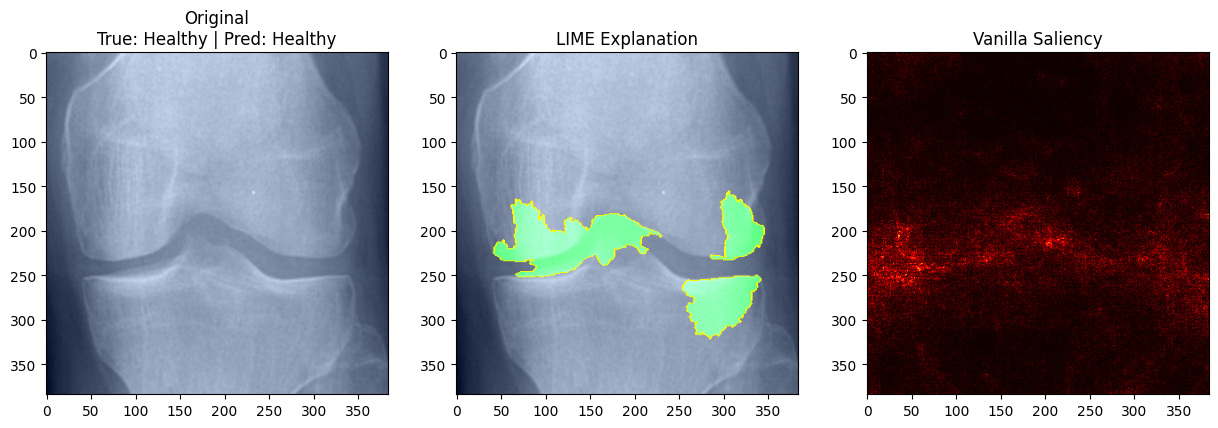

In [28]:
# ============================================================
# 11. EXPLAINABLE AI: LIME & SALIENCY MAPS
# ============================================================
from lime import lime_image
from skimage.segmentation import mark_boundaries

xai_model = cnn_model.eval().to(DEVICE)
explainer = lime_image.LimeImageExplainer()
sample_idx = 0
img_tensor, true_label = test_ds[sample_idx]

def batch_predict(images):
    xai_model.eval()
    batch = []
    for img in images:
        img_t = transforms.ToTensor()(img)
        img_t = transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])(img_t)
        batch.append(img_t.float())
    batch_tensor = torch.stack(batch).to(DEVICE)
    with torch.no_grad():
        logits = xai_model(batch_tensor)
        if isinstance(logits, tuple):
            logits = logits[0]
        probs = torch.softmax(logits, dim=1)
    return probs.cpu().numpy()

def denorm(img):
    img = img.permute(1,2,0).cpu().numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

img_np = denorm(img_tensor)
explanation = explainer.explain_instance(img_np.astype('double'), batch_predict, top_labels=3, hide_color=0, num_samples=250)
pred_cls = explanation.top_labels[0]
temp, mask = explanation.get_image_and_mask(pred_cls, positive_only=False, num_features=5, hide_rest=False)

saliency_x = img_tensor.unsqueeze(0).to(DEVICE)
saliency_x.requires_grad = True
output = xai_model(saliency_x)
if isinstance(output, tuple):
    output = output[0]
score = output[0, pred_cls]
score.backward()
saliency, _ = torch.max(saliency_x.grad.data.abs(), dim=1)
saliency_map = saliency[0].cpu().numpy()
saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min() + 1e-8)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Original\nTrue: {FINAL_CLASSES[true_label]} | Pred: {FINAL_CLASSES[pred_cls]}")
plt.subplot(1, 3, 2)
plt.imshow(mark_boundaries(temp, mask))
plt.title("LIME Explanation")
plt.subplot(1, 3, 3)
plt.imshow(saliency_map, cmap="hot")
plt.title("Vanilla Saliency")
plt.show()
